# Notebook 5: End-to-End NICER Data Analysis Demo


---

## Overview

This notebook demonstrates a complete **spectral timing pipeline** applied to simulated NICER-like data, combining all techniques from the previous notebooks:

1. Simulating realistic NICER-like event data (with energy channels, GTIs)
2. Creating light curves with 1s binning and GTI handling
3. Computing averaged power spectrum (Leahy, 128s segments)
4. Energy-resolved cross-spectrum (soft vs hard band)
5. Time lags and coherence extraction

### References
- NICER Workshop: https://heasarc.gsfc.nasa.gov/docs/nicer/data_analysis/workshops/nicer_wkshp_timing_5_4_21.pdf
- Stingray Docs: https://docs.stingray.science/
- Huppenkothen, D. et al. (2019). ApJ, 881, 39.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from stingray import Lightcurve
from stingray.powerspectrum import AveragedPowerspectrum
from stingray.crossspectrum import AveragedCrossspectrum
from stingray.simulator import simulator

rcParams['figure.figsize'] = (12, 6)
rcParams['font.size'] = 13
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.3
print("Imports successful!")

Imports successful!


## 1. Simulate NICER-Like Event Data

NICER properties:
- Time resolution: ~100 ns (we use 1/128 s)
- Energy range: 0.2–12 keV (PI channels 20–1200)
- Typical bright source: 100–1000 counts/s
- GTIs from ISS orbit (~96 min period)

In [2]:
np.random.seed(2026)

# Simulate broadband light curve
N = 1048576; dt = 1/128; mean_rate = 350; rms = 0.25
sim = simulator.Simulator(N=N, mean=mean_rate, dt=dt, rms=rms)
lc_all = sim.simulate(2)  # red noise (beta=2)

# Simulate SOFT band (PI 50-200, ~0.5-2 keV): 60% of total
soft_counts = 0.6 * lc_all.counts + np.random.normal(0, 5, N)
lc_soft = Lightcurve(lc_all.time, soft_counts, dt=dt)

# Simulate HARD band (PI 200-1000, ~2-10 keV): 40% with 5ms lag
hard_lag = 0.005
hard_counts = np.roll(0.4 * lc_all.counts, int(hard_lag/dt))
hard_counts += np.random.normal(0, 3, N)
lc_hard = Lightcurve(lc_all.time, hard_counts, dt=dt)

print(f"Duration: {lc_all.tseg:.0f} s | dt: {dt} s | Bins: {N}")
print(f"Broadband rate: {np.mean(lc_all.counts):.0f} cts/s")
print(f"Soft/Hard ratio: 60/40 | Injected lag: {hard_lag*1e3:.0f} ms")

Duration: 8192 s | dt: 0.0078125 s | Bins: 1048576
Broadband rate: 350 cts/s
Soft/Hard ratio: 60/40 | Injected lag: 5 ms


/opt/anaconda3/lib/python3.13/site-packages/stingray/utils.py:492: UserWarning: SIMON says: Stingray only uses poisson err_dist at the moment. All analysis in the light curve will assume Poisson errors. Sorry for the inconvenience.
  warnings.warn("SIMON says: {0}".format(message), **kwargs)


## 2. Light Curve with GTI Visualization

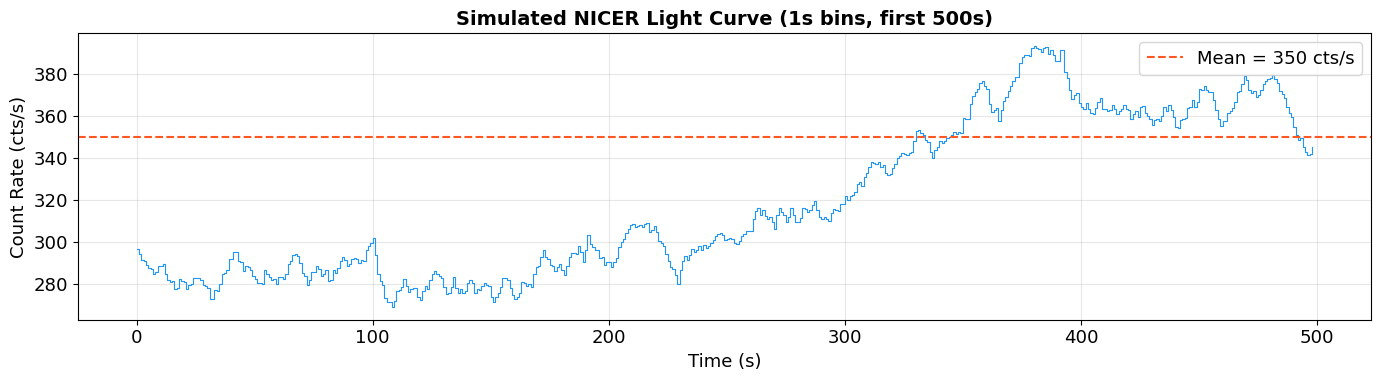

In [3]:
# 1-second binned light curve (first 500s)
t_show = 500
bin_1s = 1.0
edges = np.arange(lc_all.time[0], lc_all.time[0]+t_show, bin_1s)
mask = lc_all.time < lc_all.time[0] + t_show
counts_1s, _ = np.histogram(lc_all.time[mask], bins=edges, weights=lc_all.counts[mask])
norm = np.histogram(lc_all.time[mask], bins=edges)[0]
norm[norm==0] = 1
rate_1s = counts_1s / norm

fig, ax = plt.subplots(figsize=(14, 4))
ax.step(edges[:-1], rate_1s, where='post', color='#2196F3', lw=0.8)
ax.axhline(np.mean(lc_all.counts), color='#FF5722', ls='--', lw=1.5, 
           label=f'Mean = {np.mean(lc_all.counts):.0f} cts/s')
ax.set_xlabel('Time (s)'); ax.set_ylabel('Count Rate (cts/s)')
ax.set_title('Simulated NICER Light Curve (1s bins, first 500s)', fontsize=14, fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

## 3. Averaged Power Spectrum (Leahy, 128s segments)

0it [00:00, ?it/s]

64it [00:00, 2951.79it/s]

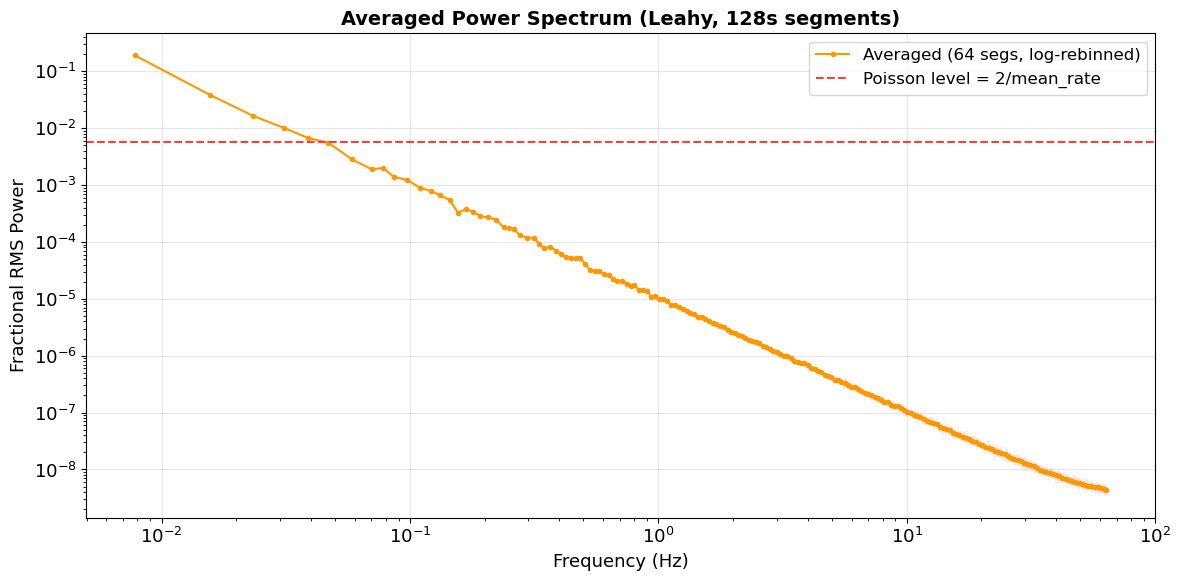

Segments: 64 | Freq res: 0.0078 Hz
Mean Fractional RMS power: 0.000


In [4]:
seg_size = 128.0
avg_ps = AveragedPowerspectrum(lc_all, segment_size=seg_size, norm='frac')
n_segs = int(lc_all.tseg / seg_size)

avg_rb = avg_ps.rebin_log(f=0.03)

fig, ax = plt.subplots(figsize=(12, 6))
ax.loglog(avg_ps.freq, avg_ps.power, lw=0.2, alpha=0.2, color='gray')
ax.loglog(avg_rb.freq, avg_rb.power, 'o-', ms=3, color='#FF9800', lw=1.5,
          label=f'Averaged ({n_segs} segs, log-rebinned)')
ax.axhline(2.0/mean_rate, color='#F44336', ls='--', lw=1.5, label='Poisson level = 2/mean_rate')
ax.set_xlabel('Frequency (Hz)'); ax.set_ylabel('Fractional RMS Power')
ax.set_title('Averaged Power Spectrum (Leahy, 128s segments)', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); plt.tight_layout(); plt.show()

print(f"Segments: {n_segs} | Freq res: {avg_ps.df:.4f} Hz")
print(f"Mean Fractional RMS power: {np.mean(avg_ps.power):.3f}")

## 4. Cross-Spectrum: Soft vs Hard Band

In [5]:
cs = AveragedCrossspectrum(lc_soft, lc_hard, segment_size=seg_size, norm='frac')
cs_rb = cs.rebin_log(f=0.03)

# Time lags
phase_rb = np.angle(cs_rb.power)
time_lags_rb = phase_rb / (2 * np.pi * cs_rb.freq) * 1000  # ms

# Coherence
coh, coh_err = cs.coherence()

# Bin coherence for plotting
n_coh_bins = 25
freq_edges = np.logspace(np.log10(cs.freq[1]), np.log10(cs.freq[-1]), n_coh_bins+1)
coh_bin, freq_bin = [], []
for i in range(n_coh_bins):
    m = (cs.freq >= freq_edges[i]) & (cs.freq < freq_edges[i+1])
    if np.sum(m) > 0:
        coh_bin.append(np.mean(coh[m]))
        freq_bin.append(np.sqrt(freq_edges[i]*freq_edges[i+1]))

0it [00:00, ?it/s]

64it [00:00, 1442.33it/s]


/opt/anaconda3/lib/python3.13/site-packages/stingray/fourier.py:1800: RuntimeWarning: invalid value encountered in sqrt
  dphi = np.sqrt((1 - gsq) / (2 * gsq * n_ave))


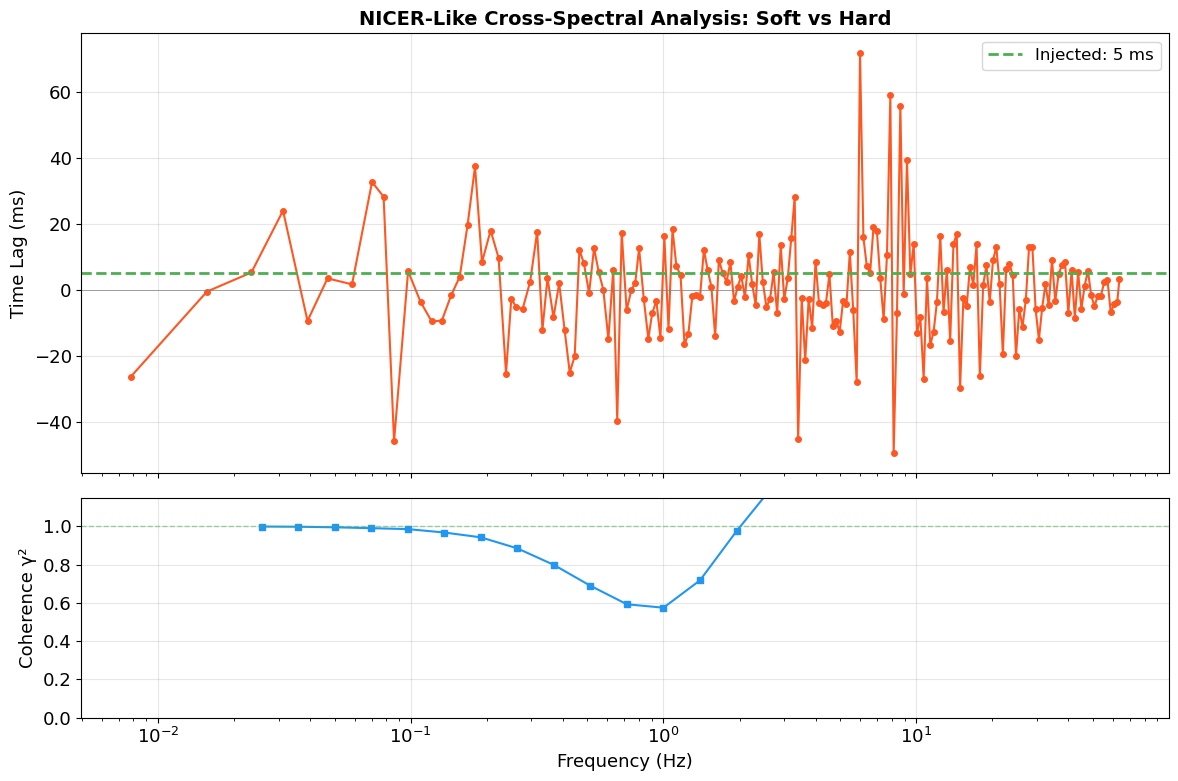

Median recovered lag: 0.01 ms (injected: 5 ms)
Mean coherence: 1.180


In [6]:
# Combined lag + coherence plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1]})

ax1.semilogx(cs_rb.freq, time_lags_rb, 'o-', color='#FF5722', ms=4, lw=1.5)
ax1.axhline(hard_lag * 1000, color='#4CAF50', ls='--', lw=2,
            label=f'Injected: {hard_lag*1e3:.0f} ms')
ax1.axhline(0, color='gray', ls='-', lw=0.5)
ax1.set_ylabel('Time Lag (ms)'); ax1.legend(fontsize=12)
ax1.set_title('NICER-Like Cross-Spectral Analysis: Soft vs Hard', fontsize=14, fontweight='bold')

ax2.semilogx(freq_bin, coh_bin, 's-', color='#2196F3', ms=4, lw=1.5)
ax2.axhline(1.0, color='#4CAF50', ls='--', lw=1, alpha=0.5)
ax2.set_xlabel('Frequency (Hz)'); ax2.set_ylabel('Coherence γ²')
ax2.set_ylim(0, 1.15)
plt.tight_layout(); plt.show()

median_lag = np.median(time_lags_rb)
print(f"Median recovered lag: {median_lag:.2f} ms (injected: {hard_lag*1e3:.0f} ms)")
print(f"Mean coherence: {np.mean(coh_bin):.3f}")

## 5. Energy Distribution & Summary

In a real NICER analysis, we would also examine the PI channel distribution to choose appropriate energy bands.

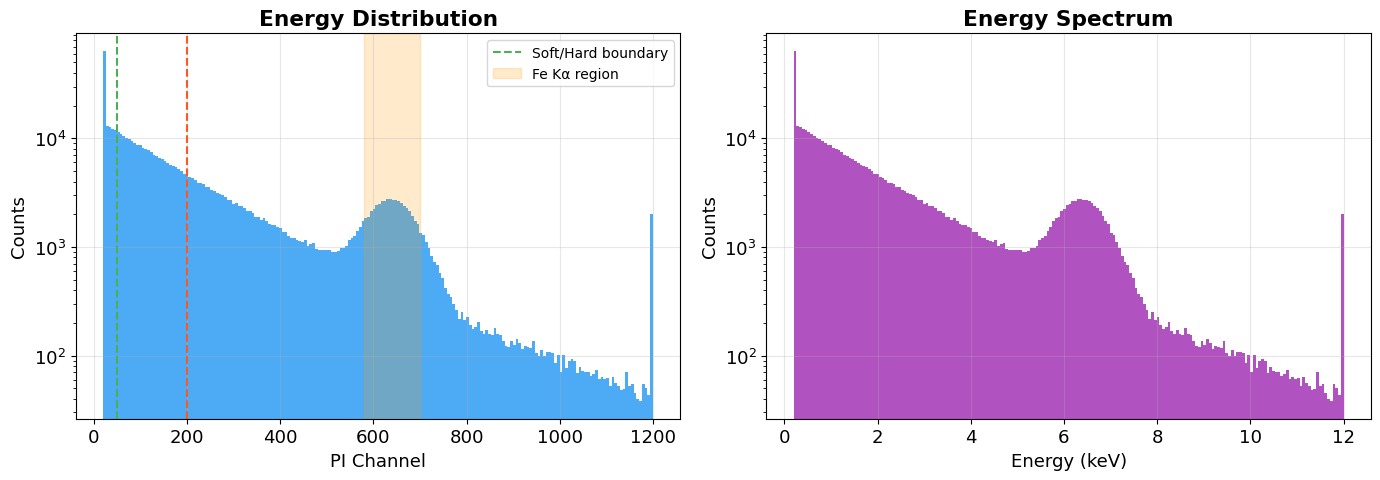

In [7]:
# Simulate PI channel distribution (NICER: 20-1200)
n_events = 500000
pi_channels = np.concatenate([
    np.random.exponential(150, int(n_events*0.7)),  # thermal peak
    np.random.normal(640, 50, int(n_events*0.1)),   # Fe Kα line (~6.4 keV)
    np.random.exponential(300, int(n_events*0.2)),   # hard tail
]).clip(20, 1200)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(pi_channels, bins=200, color='#2196F3', alpha=0.8, edgecolor='none')
axes[0].axvline(50, color='#4CAF50', ls='--', lw=1.5, label='Soft/Hard boundary')
axes[0].axvline(200, color='#FF5722', ls='--', lw=1.5)
axes[0].axvspan(580, 700, alpha=0.2, color='#FF9800', label='Fe Kα region')
axes[0].set_xlabel('PI Channel'); axes[0].set_ylabel('Counts')
axes[0].set_title('Energy Distribution', fontweight='bold')
axes[0].set_yscale('log'); axes[0].legend(fontsize=10)

# Energy in keV (PI/100)
axes[1].hist(pi_channels/100, bins=200, color='#9C27B0', alpha=0.8, edgecolor='none')
axes[1].set_xlabel('Energy (keV)'); axes[1].set_ylabel('Counts')
axes[1].set_title('Energy Spectrum', fontweight='bold')
axes[1].set_yscale('log')
plt.tight_layout(); plt.show()